# Station N16 Analysis

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [26]:
# Load cleaned dataset for station N16
n16_data = pd.read_csv('../../Station_Datasets/n16_data.csv')
display(n16_data.head())

,Sampling Location,Sample Date,Top Sample Temperature (ºC),Winkler Method Top Dissolved Oxygen (mg/L),Top Salinity (psu),Top PH,Secchi Depth (ft),Top Active Chlorophyll 'A' (µg/L),Total Phosphorus(mg/L),Top Ammonium (mg/L),Top Total Kjeldhal Nitrogen (mg/L),Top Nitrate/Nitrite (mg/L)
0,N16,1995-06-21,16.10,8.32,30.94,7.85,7.0,23.8,0.070,0.007,NaN,0.009
1,N16,1995-07-13,20.34,8.44,30.56,7.94,6.0,9.3,0.065,0.110,NaN,0.009
2,N16,1995-07-27,19.05,5.61,31.47,7.61,9.0,83.8,0.100,0.054,NaN,0.011
3,N16,1995-08-22,24.52,8.45,29.36,7.99,4.5,38.0,0.110,0.026,NaN,0.071
4,N16,1995-08-29,22.30,8.42,30.73,8.21,5.5,14.3,0.075,0.010,NaN,0.005


## Data normalization and calculations

See the distribution of features across the dataset

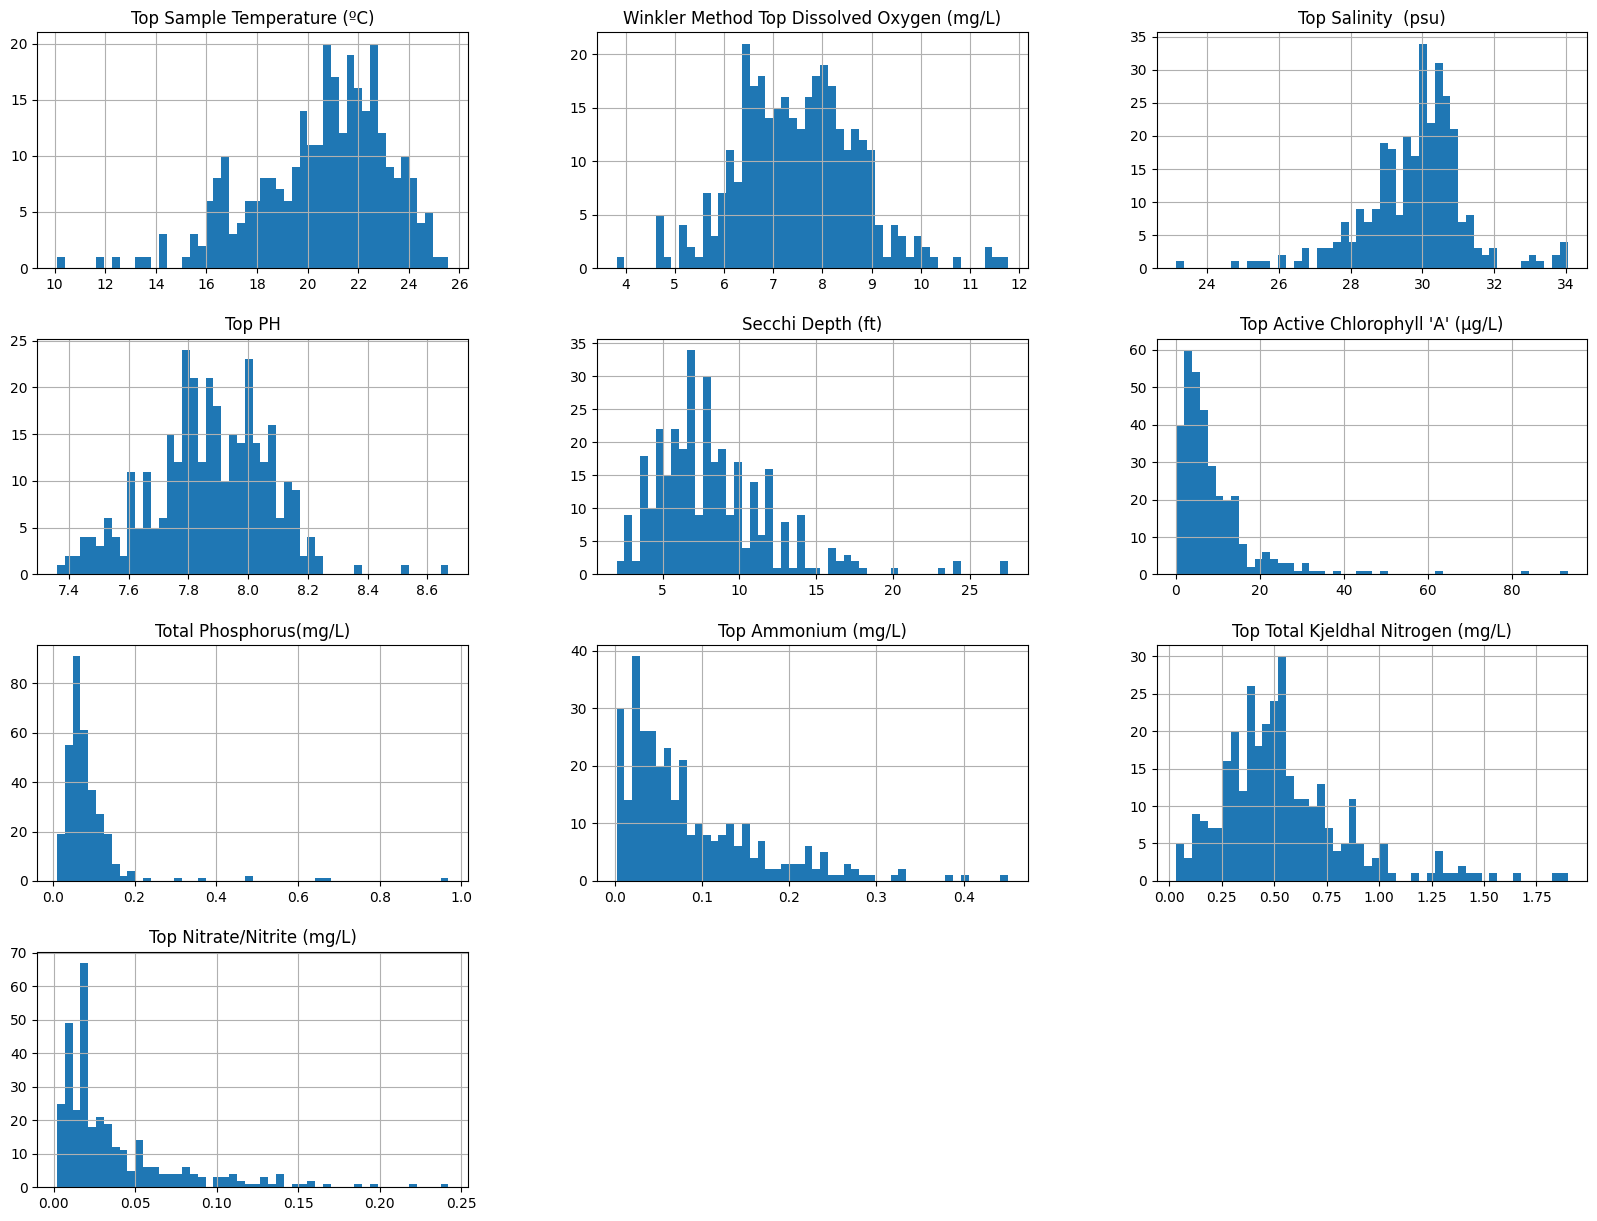

In [27]:
# Create dataframe without sample date  and sampling location columns
columns_to_drop = ['Sampling Location','Sample Date']
n16_features = n16_data.drop(columns_to_drop, axis=1)

#Visualize histograms of all variables within n16_features
n16_features.hist(bins=50, figsize=(20, 15))
plt.show()

Some features were log-transformed in order to generate normal distribution. Since we want to see the yearly variance within stations, instead of clustering the stations, we will normalize the variables individually for each station.

Data after log transformation:


,Top Sample Temperature (ºC),Winkler Method Top Dissolved Oxygen (mg/L),Top Salinity (psu),Top PH,Secchi Depth (ft),Top Active Chlorophyll 'A' (µg/L),Total Phosphorus(mg/L),Top Ammonium (mg/L),Top Total Kjeldhal Nitrogen (mg/L),Top Nitrate/Nitrite (mg/L)
0,16.10,2.118662,30.94,7.85,1.945910,3.169686,-2.659260,-4.961845,NaN,-4.710531
1,20.34,2.132982,30.56,7.94,1.791759,2.230014,-2.733368,-2.207275,NaN,-4.710531
2,19.05,1.724551,31.47,7.61,2.197225,4.428433,-2.302585,-2.918771,NaN,-4.509860
3,24.52,2.134166,29.36,7.99,1.504077,3.637586,-2.207275,-3.649659,NaN,-2.645075
4,22.30,2.130610,30.73,8.21,1.704748,2.660260,-2.590267,-4.605170,NaN,-5.298317


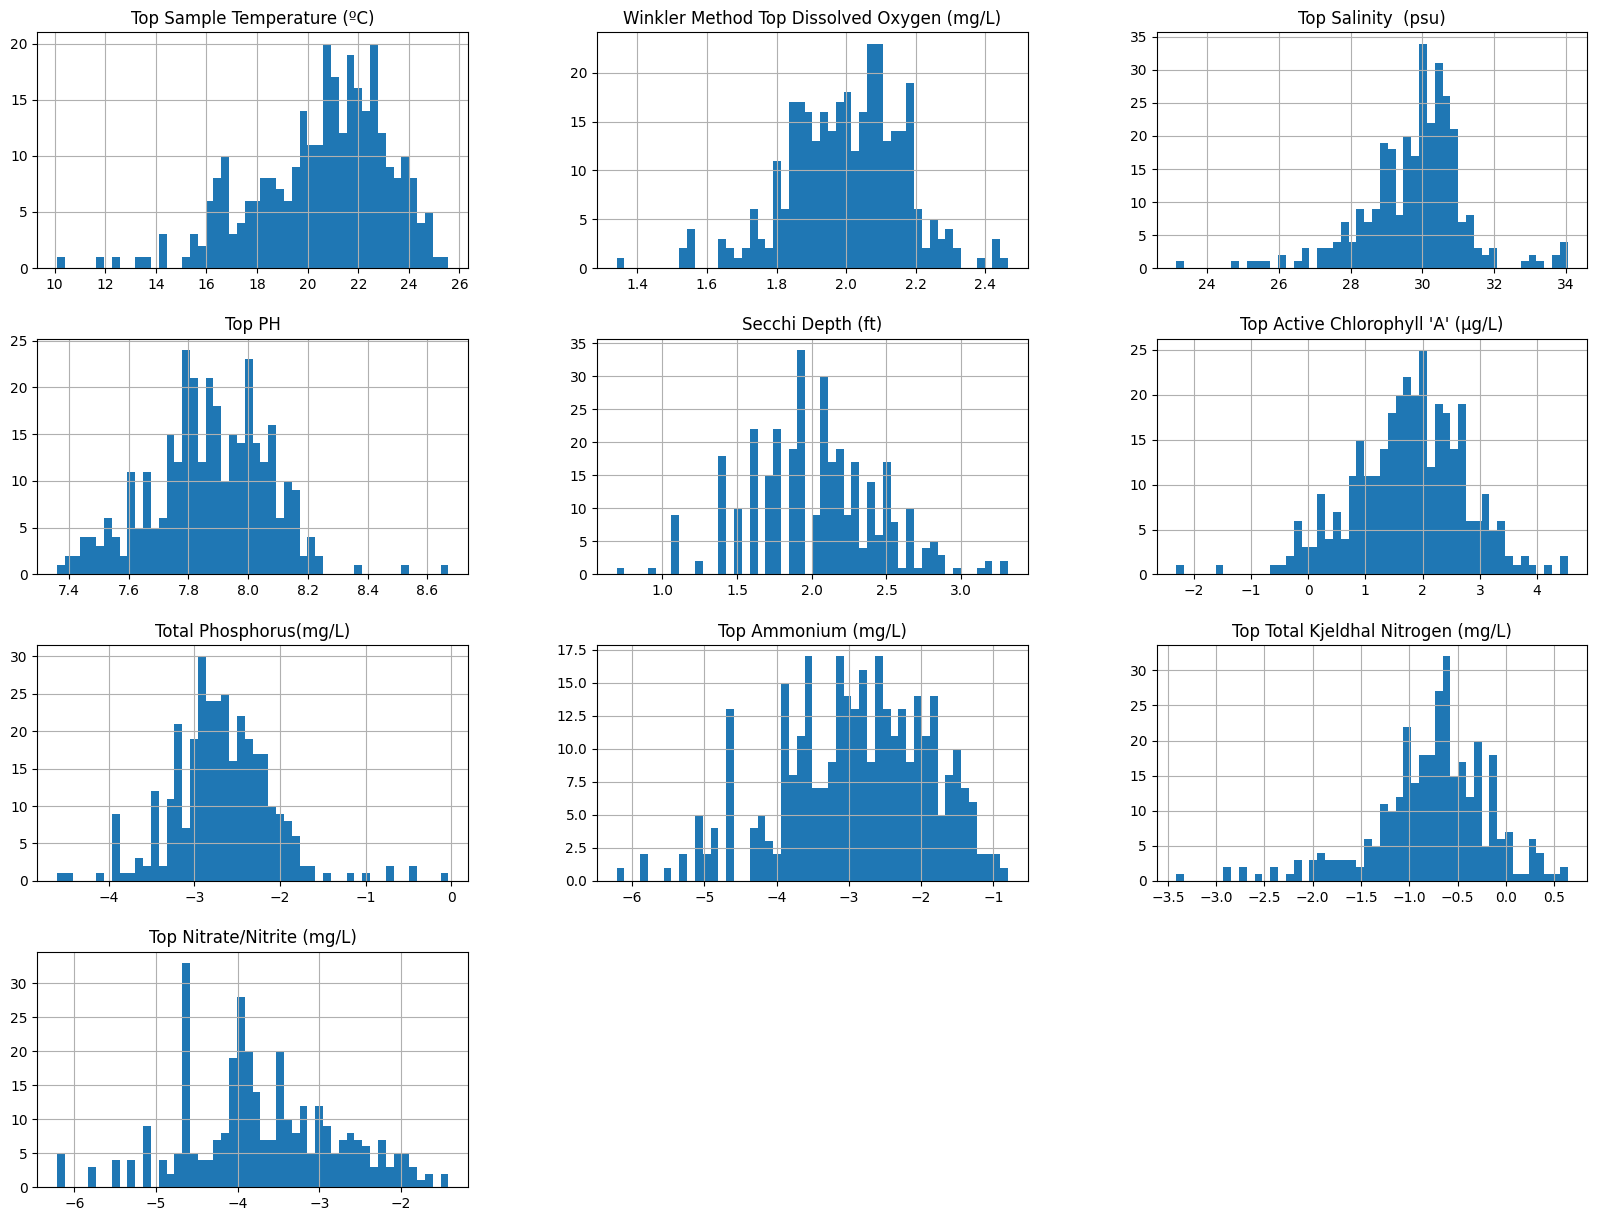

In [28]:
n16_features_transformed = n16_features.copy()

# Define the list of columns to be log-transformed
log_transform_cols = [
    'Winkler Method Top Dissolved Oxygen (mg/L)',
    'Secchi Depth (ft)',
    "Top Active Chlorophyll 'A' (µg/L)",
    'Total Phosphorus(mg/L)',
    'Top Ammonium (mg/L)',
    'Top Total Kjeldhal Nitrogen (mg/L)',
    'Top Nitrate/Nitrite (mg/L)'
]

# Apply log1p transformation to the selected columns
for col in log_transform_cols:
    # For this specific dataset, we will proceed assuming non-negative values where log is appropriate.
    n16_features_transformed[col] = np.log(n16_features_transformed[col])

print("Data after log transformation:")
display(n16_features_transformed.head())

# Optionally, visualize histograms of the transformed columns to check distribution
n16_features_transformed.hist(bins=50, figsize=(20, 15))
plt.show()

Scale all relevant features EXCEPT 'Sample Date' using StandardScaler

In [29]:
# Scale features
n16_features_scaled = StandardScaler().fit_transform(n16_features_transformed)

# Add scaled features back into the dataset WITH the year
n16_scaled_df = pd.DataFrame(n16_features_scaled, columns=n16_features_transformed.columns)
n16_scaled_df['Date'] = pd.to_datetime(n16_data['Sample Date']).values

display(n16_scaled_df)

,Top Sample Temperature (ºC),Winkler Method Top Dissolved Oxygen (mg/L),Top Salinity (psu),Top PH,Secchi Depth (ft),Top Active Chlorophyll 'A' (µg/L),Total Phosphorus(mg/L),Top Ammonium (mg/L),Top Total Kjeldhal Nitrogen (mg/L),Top Nitrate/Nitrite (mg/L),Date
0,-1.688296,0.706862,0.796939,-0.112778,-0.218601,1.451572,0.037192,-2.024231,NaN,-1.080753,1995-06-21
1,-0.076749,0.793410,0.531451,0.345296,-0.577548,0.482057,-0.087281,0.680512,NaN,-1.080753,1995-07-13
2,-0.567054,-1.675076,1.167225,-1.334309,0.366595,2.750298,0.636274,-0.018114,NaN,-0.866787,1995-07-27
3,1.511994,0.800567,-0.306933,0.599782,-1.247428,1.934333,0.796360,-0.735780,NaN,1.121551,1995-08-22
4,0.668212,0.779071,0.650222,1.719518,-0.780157,0.925967,0.153075,-1.674008,NaN,-1.707484,1995-08-29
...,...,...,...,...,...,...,...,...,...,...,...
381,0.491683,0.507476,-0.049409,0.956061,-0.577548,1.416295,0.175322,-0.197138,0.284636,-0.284031,2024-08-06
382,0.237047,-0.017723,0.067545,0.752473,0.366595,0.260113,-0.430086,0.133248,0.220417,0.202990,2024-08-13
383,0.300464,-0.647227,-0.577556,0.548884,-0.218601,1.079846,1.294759,-0.197138,0.083940,0.561755,2024-08-27
384,0.388928,0.167759,0.178142,1.312341,-0.577548,0.692122,-0.430086,-0.197138,0.239023,-0.284031,2024-09-04


Take yearly means

In [30]:
# Take yearly means
n16_yearly_means = n16_scaled_df.groupby(n16_scaled_df['Date'].dt.year).mean()
display(n16_yearly_means.head())

,Top Sample Temperature (ºC),Winkler Method Top Dissolved Oxygen (mg/L),Top Salinity (psu),Top PH,Secchi Depth (ft),Top Active Chlorophyll 'A' (µg/L),Total Phosphorus(mg/L),Top Ammonium (mg/L),Top Total Kjeldhal Nitrogen (mg/L),Top Nitrate/Nitrite (mg/L),Date
Date,,,,,,,,,,,
1995,0.077999,0.106381,0.533447,0.243502,-0.550057,1.399744,0.477055,-0.339809,NaN,-0.256763,1995-08-11 03:25:42.857142
1996,-0.420723,-0.016284,-0.515530,-0.294554,-0.071764,0.397187,0.247922,0.153252,0.160032,0.520084,1996-08-07 12:00:00.000000
1997,-0.451647,0.112979,-0.047161,-0.469058,0.395248,0.623068,0.178035,-0.287377,-0.178284,-0.124603,1997-07-23 22:00:00.000000
1998,-0.312822,0.058132,-0.691968,0.529798,0.884464,-0.141589,-0.434126,-0.330763,0.565762,-0.325356,1998-07-20 13:05:27.272727
1999,0.010670,-0.027850,0.532848,-1.395386,0.568688,0.386787,0.176438,-0.162519,0.531281,-0.222965,1999-07-24 09:36:00.000000


In [31]:
# Check to ensure all columns exist correctly in the yearly means dataframe
print(n16_yearly_means.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['Top Sample Temperature (ºC)',
       'Winkler Method Top Dissolved Oxygen (mg/L)', 'Top Salinity  (psu)',
       'Top PH', 'Secchi Depth (ft)', 'Top Active Chlorophyll 'A' (µg/L)',
       'Total Phosphorus(mg/L)', 'Top Ammonium (mg/L)',
       'Top Total Kjeldhal Nitrogen (mg/L)', 'Top Nitrate/Nitrite (mg/L)',
       'Date'],
      dtype='str')>


## PCA and PCA Visualizations

Drop the date column before running PCA on the features

In [32]:
#Drop date before PCA
feature_means = n16_yearly_means[[
    'Top Sample Temperature (ºC)',
    'Winkler Method Top Dissolved Oxygen (mg/L)',
    'Top Salinity  (psu)',
    'Top PH',
    'Secchi Depth (ft)',
    'Top Active Chlorophyll \'A\' (µg/L)',
    'Total Phosphorus(mg/L)',
    'Top Ammonium (mg/L)',
    'Top Total Kjeldhal Nitrogen (mg/L)',
    'Top Nitrate/Nitrite (mg/L)'
]]

print(feature_means.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['Top Sample Temperature (ºC)',
       'Winkler Method Top Dissolved Oxygen (mg/L)', 'Top Salinity  (psu)',
       'Top PH', 'Secchi Depth (ft)', 'Top Active Chlorophyll 'A' (µg/L)',
       'Total Phosphorus(mg/L)', 'Top Ammonium (mg/L)',
       'Top Total Kjeldhal Nitrogen (mg/L)', 'Top Nitrate/Nitrite (mg/L)'],
      dtype='str')>


In [33]:
# Checking for null values in the feature_means dataframe
print(feature_means.isnull().sum())

Top Sample Temperature (ºC)                   0
Winkler Method Top Dissolved Oxygen (mg/L)    0
Top Salinity  (psu)                           0
Top PH                                        0
Secchi Depth (ft)                             0
Top Active Chlorophyll 'A' (µg/L)             0
Total Phosphorus(mg/L)                        0
Top Ammonium (mg/L)                           0
Top Total Kjeldhal Nitrogen (mg/L)            1
Top Nitrate/Nitrite (mg/L)                    0
dtype: int64


There is one null value in the 'Total Kjeldhal Nitrogen (mg/L)' column. I want to know where the missing value is.

In [34]:
print("Row(s) with missing Top Total Kjeldhal Nitrogen (mg/L):")
display(feature_means[feature_means['Top Total Kjeldhal Nitrogen (mg/L)'].isnull()])

Row(s) with missing Top Total Kjeldhal Nitrogen (mg/L):


,Top Sample Temperature (ºC),Winkler Method Top Dissolved Oxygen (mg/L),Top Salinity (psu),Top PH,Secchi Depth (ft),Top Active Chlorophyll 'A' (µg/L),Total Phosphorus(mg/L),Top Ammonium (mg/L),Top Total Kjeldhal Nitrogen (mg/L),Top Nitrate/Nitrite (mg/L)
Date,,,,,,,,,,
1995,0.077999,0.106381,0.533447,0.243502,-0.550057,1.399744,0.477055,-0.339809,NaN,-0.256763


Since there is only one row with missing values, and this row is the first in the dataframe, we will drop it for PCA analysis.

In [35]:
#Import libraries
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

In [36]:
# Initialize PCA and drop extra row
pca = PCA(n_components=2)
# Drop rows with NaN values before PCA
feature_means = feature_means.dropna()

In [37]:
# Run PCA on feature means
feature_means_pca = pca.fit_transform(feature_means)  # shape: (n_samples, 2)
loadings = pca.components_.T                          # shape: (n_features, 2)

In [38]:
# Ensuring the index is explicitly set to the years for plotting
feature_means_pca_df = pd.DataFrame(feature_means_pca, columns=['PC1', 'PC2'], index=feature_means.index)
display(feature_means_pca_df.head())

,PC1,PC2
Date,,
1996,-0.023091,-0.664570
1997,0.424936,-0.217355
1998,0.476921,-0.548726
1999,1.179237,0.285129
2000,1.027268,-0.280192


In [39]:
# See the explained variance ratio to understand how much variance is captured by the first two principal components
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance ratio by PC1 and PC2: {explained_variance}")

Explained variance ratio by PC1 and PC2: [0.28199739 0.24469079]


Now we have PC1 and PC2, along with the year. We now want to generate the plot to visualize the PCA.

In [40]:
#Generating a list of shorter names for the columns, so that the final visualization is less cluttered.
feature_names_short = [
    'Temp (°C)',
    'DO (mg/L)',
    'Salinity (psu)',
    'pH',
    'Secchi (ft)',
    'ChlA (µg/L)',
    'P (mg/L)',
    'NH4 (mg/L)',
    'TKN (mg/L)',
    'NO3+NO2 (mg/L)'
]

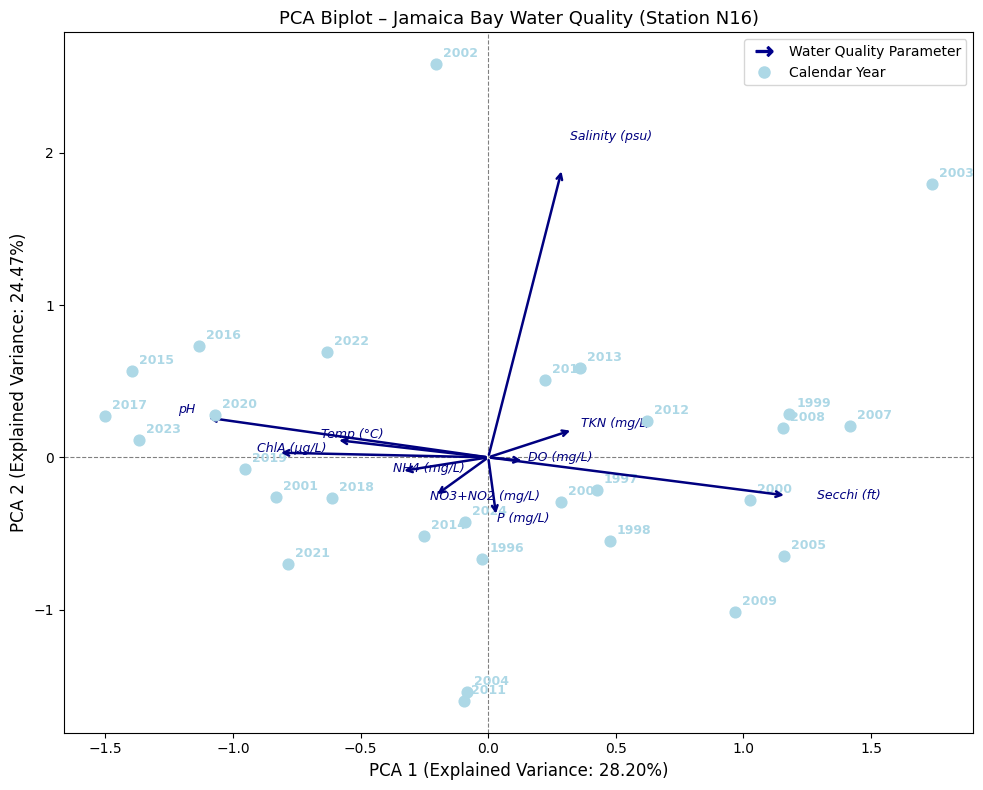

In [41]:
# Generating the plot
fig, ax = plt.subplots(figsize=(10, 8))

# --- Plot yearly points ---
ax.scatter(feature_means_pca_df['PC1'], feature_means_pca_df['PC2'], color='lightblue', zorder=5, s=60)
for _, row in feature_means_pca_df.iterrows():
    ax.annotate(str(int(row.name)), xy=(row['PC1'], row['PC2']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color='lightblue', fontweight='bold')

# --- Scale factor for arrows (tune as needed) ---
scale = 2.0

# --- Plot loading arrows ---
for i, name in enumerate(feature_names_short):
    x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.8))
    ax.text(x * 1.1, y * 1.1, name, fontsize=9, color='navy', fontstyle='italic')

# --- Reference lines ---
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# --- Labels ---
ax.set_xlabel(f'PCA 1 (Explained Variance: {explained_variance[0] * 100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PCA 2 (Explained Variance: {explained_variance[1] * 100:.2f}%)', fontsize=12)
ax.set_title('PCA Biplot – Jamaica Bay Water Quality (Station N16)', fontsize=13)

# --- Legend ---
arrow_patch = mpatches.FancyArrow(0, 0, 0, 0, color='darkblue')
point_patch = mpatches.Patch(color='lightblue', label='Calendar Year')
ax.legend(handles=[
    plt.Line2D([0], [0], marker=r'$\rightarrow$', color='darkblue',
               markersize=12, label='Water Quality Parameter', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='lightblue',
               markersize=8, label='Calendar Year', linestyle='None')
], loc='upper right')

plt.tight_layout()
plt.savefig('jamaica_bay_pca_n16.png', dpi=300, bbox_inches='tight')
plt.show()

## K-Means Clustering

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

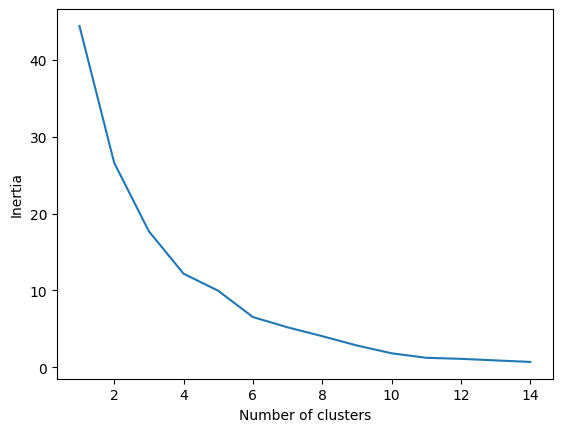

In [43]:
# plot the elbow visualization
inertiaVals1 = {}

for k in range(1, 15):
    kmeansK1 = KMeans(n_clusters=k, max_iter=1000).fit(feature_means_pca_df)
    inertiaVals1[k] = kmeansK1.inertia_
plt.figure()
plt.plot(list(inertiaVals1.keys()), list(inertiaVals1.values()))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [44]:
# Find optimal number of clusters
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(feature_means_pca_df[['PC1', 'PC2']])
    score = silhouette_score(feature_means_pca_df[['PC1', 'PC2']], labels)
    print(f"k={k}, silhouette score: {score:.3f}")

k=2, silhouette score: 0.402
k=3, silhouette score: 0.429
k=4, silhouette score: 0.401
k=5, silhouette score: 0.369
k=6, silhouette score: 0.369


Two and three clusters seem ideal. I will start by visualizing those.

In [45]:
# Use best k
kmeans = KMeans(n_clusters=2, random_state=42)
feature_means_pca_df['Cluster'] = kmeans.fit_predict(feature_means_pca_df[['PC1', 'PC2']])
print(feature_means_pca_df[['Cluster']].sort_values('Cluster'))

      Cluster
Date         
1996        0
1997        0
1998        0
1999        0
2000        0
2003        0
2005        0
2004        0
2008        0
2009        0
2006        0
2007        0
2010        0
2011        0
2013        0
2012        0
2014        0
2024        0
2001        1
2002        1
2016        1
2017        1
2018        1
2015        1
2019        1
2020        1
2022        1
2021        1
2023        1


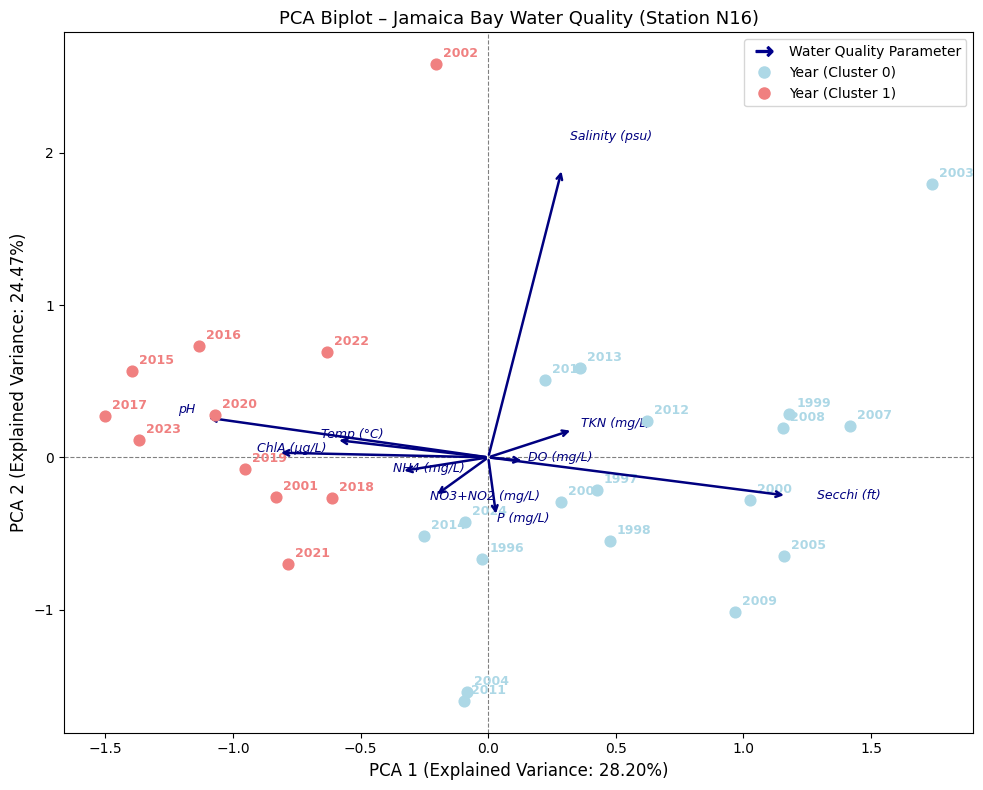

In [46]:
# Generating the plot – colored by cluster
fig, ax = plt.subplots(figsize=(10, 8))

cluster_colors = {0: 'lightblue', 1: 'lightcoral'}

# --- Plot yearly points ---
for idx, row in feature_means_pca_df.iterrows():
    color = cluster_colors[row['Cluster']]
    ax.scatter(row['PC1'], row['PC2'], color=color, zorder=5, s=60)
    ax.annotate(str(int(idx)), xy=(row['PC1'], row['PC2']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

# --- Scale factor for arrows ---
scale = 2.0

# --- Plot loading arrows ---
for i, name in enumerate(feature_names_short):
    x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.8))
    ax.text(x * 1.1, y * 1.1, name, fontsize=9, color='navy', fontstyle='italic')

# --- Reference lines ---
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# --- Labels ---
ax.set_xlabel(f'PCA 1 (Explained Variance: {explained_variance[0] * 100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PCA 2 (Explained Variance: {explained_variance[1] * 100:.2f}%)', fontsize=12)
ax.set_title('PCA Biplot – Jamaica Bay Water Quality (Station N16)', fontsize=13)

# --- Legend ---
ax.legend(handles=[
    plt.Line2D([0], [0], marker=r'$\rightarrow$', color='darkblue',
               markersize=12, label='Water Quality Parameter', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='lightblue',
               markersize=8, label='Year (Cluster 0)', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='lightcoral',
               markersize=8, label='Year (Cluster 1)', linestyle='None'),
], loc='upper right')

plt.tight_layout()
plt.savefig('jamaica_bay_pca_n16_2clusters.png', dpi=300, bbox_inches='tight')
plt.show()

Doing the same with 3 clusters

In [47]:
# Use best k
kmeans1 = KMeans(n_clusters=3, random_state=42)
feature_means_pca_df['Cluster'] = kmeans1.fit_predict(feature_means_pca_df[['PC1', 'PC2']])
print(feature_means_pca_df[['Cluster']].sort_values('Cluster'))

      Cluster
Date         
1996        0
1997        0
1998        0
1999        0
2000        0
2006        0
2005        0
2004        0
2008        0
2009        0
2010        0
2007        0
2011        0
2014        0
2013        0
2012        0
2024        0
2019        1
2001        1
2020        1
2016        1
2017        1
2018        1
2015        1
2023        1
2021        1
2022        1
2003        2
2002        2


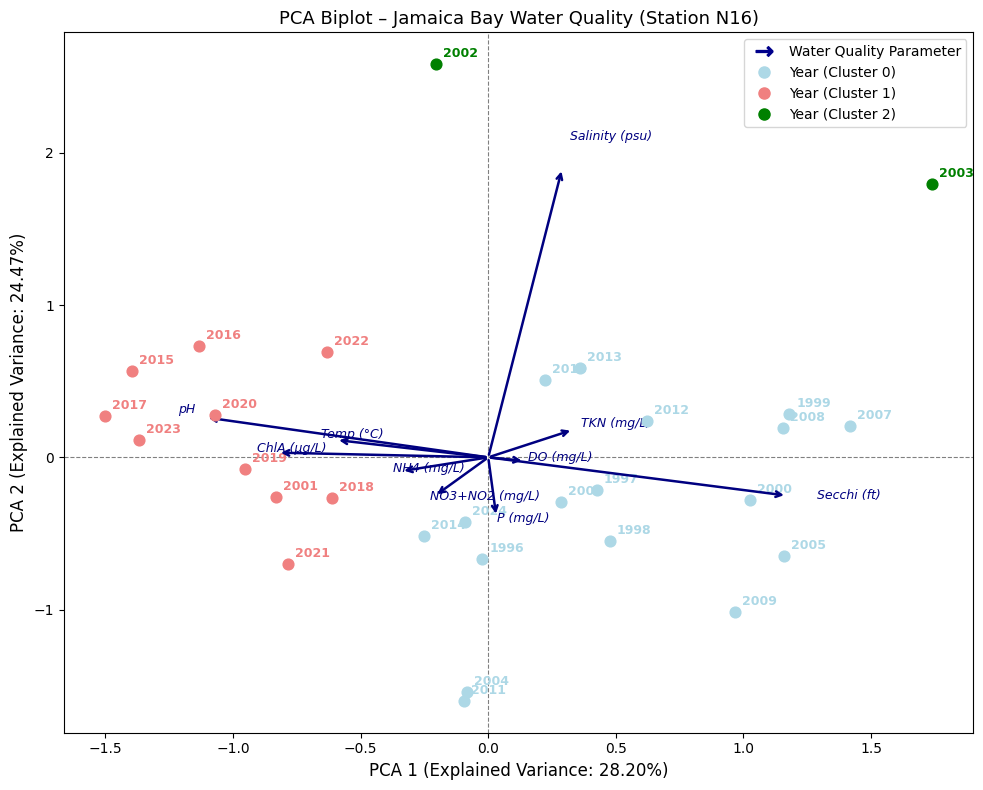

In [48]:
# PCA biplot with 3 clusters
fig, ax = plt.subplots(figsize=(10, 8))

cluster_colors = {0: 'lightblue', 1: 'lightcoral', 2: 'green'}
# --- Plot yearly points ---
for idx, row in feature_means_pca_df.iterrows():
    color = cluster_colors[row['Cluster']]
    ax.scatter(row['PC1'], row['PC2'], color=color, zorder=5, s=60)
    ax.annotate(str(int(idx)), xy=(row['PC1'], row['PC2']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

# --- Scale factor for arrows ---
scale = 2.0

# --- Plot loading arrows ---
for i, name in enumerate(feature_names_short):
    x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.8))
    ax.text(x * 1.1, y * 1.1, name, fontsize=9, color='navy', fontstyle='italic')

# --- Reference lines ---
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# --- Labels ---
ax.set_xlabel(f'PCA 1 (Explained Variance: {explained_variance[0] * 100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PCA 2 (Explained Variance: {explained_variance[1] * 100:.2f}%)', fontsize=12)
ax.set_title('PCA Biplot – Jamaica Bay Water Quality (Station N16)', fontsize=13)

# --- Legend ---
ax.legend(handles=[
    plt.Line2D([0], [0], marker=r'$\rightarrow$', color='darkblue',
               markersize=12, label='Water Quality Parameter', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='lightblue',
               markersize=8, label='Year (Cluster 0)', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='lightcoral',
               markersize=8, label='Year (Cluster 1)', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='green',
               markersize=8, label='Year (Cluster 2)', linestyle='None'),
], loc='upper right')

plt.tight_layout()
plt.savefig('jamaica_bay_pca_n16_3clusters.png', dpi=300, bbox_inches='tight')
plt.show()